In [1]:
from util.text_util import join_texts
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
import os
from mcp4cm.bpmn.dataloading.dataloading import BPMNModelCollection
from mcp4cm.bpmn.dataloading.bpmn_dataset import BPMNDataset
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType

Defining file path for saving dataset and loading it later on.

In [3]:
bpmn_dataset = load_dataset(path='data/bpmnmodelset', dataset_type=DatasetType.BPMNMODELSET, bpmn_model_collection=BPMNModelCollection.SAP_SAM)

Loading SAP SAM Dataset @ data/bpmnmodelset\sap_sam_2022/models: 100%|██████████| 103/103 [12:27<00:00,  7.26s/it]


In [4]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models
from mcp4cm.bpmn.constants import NAMES_WITH_TYPES_COLUMN, NAMES_COLUMN, EMPTY_NAME_TOKEN, BASE_BPMN_DATASETS_PATH

use_types = False
empty_name = EMPTY_NAME_TOKEN
checkpoint_folder = 'processed/sap_sam_2022'

if use_types:
    key = NAMES_WITH_TYPES_COLUMN
    checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'typed_names.csv')
else:
    key = NAMES_COLUMN
    checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'names_only.csv')


extract_names_from_models(bpmn_dataset, use_types=use_types, include_texts=True, include_documentation=True)


In [5]:
BPMNDataset.to_csv(bpmn_dataset, fp=checkpoint_path)

In [6]:
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv

del bpmn_dataset

bpmn_dataset = load_processed_dataset_from_csv("SAP_SAM", checkpoint_path)


In [7]:

from bpmn.filter_functions import filter_empty_models, filter_models_by_min_element_count, \
    filter_models_by_max_element_count, filter_models_by_element_count, filter_models_by_empty_name_percentage, \
    filter_models_by_dummy_words, filter_models_by_median_name_length, filter_models_by_required_elements, \
    filter_models_by_duplicate_activities
from mcp4cm.dataloading import Dataset

print(bpmn_dataset)
Dataset.apply_filters(
    dataset=bpmn_dataset,
    filters=[
        filter_empty_models,
        filter_models_by_empty_name_percentage,
        filter_models_by_min_element_count,
        filter_models_by_required_elements,
        filter_models_by_dummy_words,
        filter_models_by_median_name_length,
        #filter_models_by_duplicate_activities
    ],
)

print(bpmn_dataset)

Dataset(name=SAP_SAM, models=618807)
Filtered out models where every element is unnamed: 16902
Filtered out models with a empty name percentage higher than 0.35: 7
Filtered out models with element counts smaller than 5: 2262
Filtered out models which do not have minimally required elements: 29371
Filtered out models with a dummy_percentage higher than 0.6: 201
Filtered out models with a median name length smaller than 3: 15918


ValueError: This analysis can only be done if name and types were extracted.

In [8]:
print(bpmn_dataset)

Dataset(name=SAP_SAM, models=554146)


In [11]:
from mcp4cm.language_detection import extract_dataset_languages, get_models_by_language

extract_dataset_languages(bpmn_dataset, text_key=key, empty_name=empty_name, override=False)


Language Extraction Progress:   0%|          | 0/554146 [00:00<?, ?it/s]

In [12]:
from mcp4cm.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)

print(f"Filtered Dataset to {len(english_dataset)} English models.")

del bpmn_dataset

Filtered Dataset to 328891 English models.


In [13]:
checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'english_typed_names.csv')
BPMNDataset.to_csv(english_dataset, checkpoint_path);
print(f"Saved {len(english_dataset)} models in dataset {english_dataset.name} to csv file")


Saved 328891 models in dataset SAP_SAM to csv file



=== Dataset Statistics ===
Hash calculation and duplicate detection took 2.34 seconds.
Total number of models: 328891
Total unique files: 123578
Total duplicate files: 205313
Number of duplicate groups: 14688


C:\Entwicklung\BA_EAKG\mcp4cm\bpmn\data_extraction.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.models[HASH_COLUMN] = dataset.models[key].apply(lambda texts: get_file_hash(json.dumps(texts)))


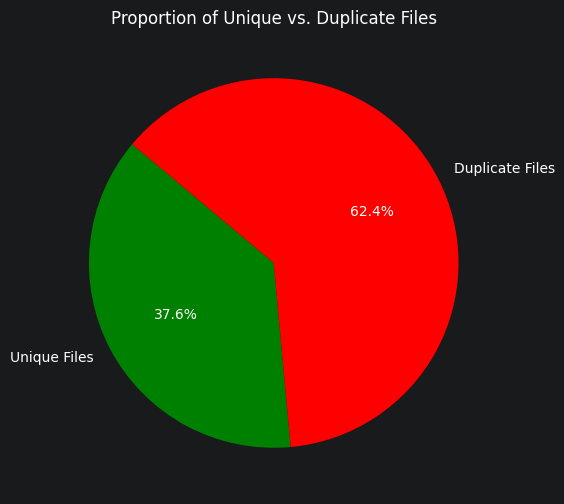

(Dataset(name=SAP_SAM_unique, models=123578),
 Dataset(name=SAP_SAM_duplicates, models=205313))

In [14]:
from mcp4cm.duplicate_detection import detect_duplicates_by_hash
detect_duplicates_by_hash(english_dataset, key=key, inplace=True, plt_fig=True, print_results=True, keep_one=False)


creating tfidf for names
Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 101982
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 123578
Total unique files: 94494
Total duplicate files: 29084
Number of duplicate groups: 7488


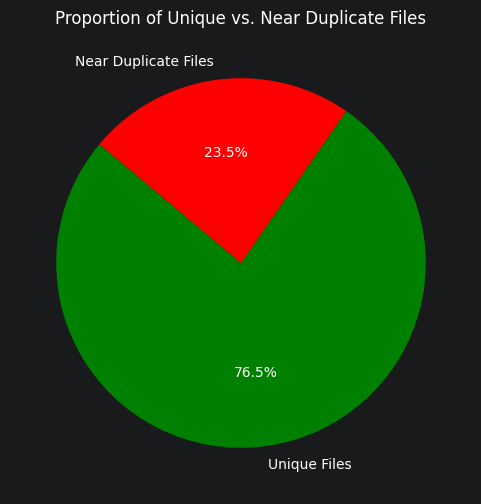

(Dataset(name=SAP_SAM_unique, models=94494),
 Dataset(name=SAP_SAM_duplicates, models=29084))

In [15]:
from mcp4cm.duplicate_detection import tfidf_near_duplicate_detector
tfidf_near_duplicate_detector(english_dataset,key=key, threshold=0.95, inplace=True, plt_fig=True, print_results=True, keep_one=False)

In [16]:
filtered_checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'english_filtered_deduplicated_typed.csv')
BPMNDataset.to_csv(english_dataset, filtered_checkpoint_path)

BPMNDataset.to_files(english_dataset, output_directory='data/export/sap_sam_typed_clean', include_svg=False)